<a href="https://colab.research.google.com/github/lohaniSatwik/steam-games-data-mining/blob/master/Code/section4a_logistic_ros_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/lohaniSatwik/steam-games-data-mining/blob/master/Code/section4a_logistic_ros_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section 4a (Extra) — Logistic Regression + Random Over-Sampling
**IE500 Data Mining | Team 9 – Brewed Clusters**

> **Google Colab notebook.** Run all cells top to bottom.

### Purpose
This notebook tests whether **Random Over-Sampling (ROS)** improves Logistic Regression performance  
compared to the `class_weight='balanced'` baseline (Macro F1 = **0.4355**).

### Key design choices
- **No** `class_weight='balanced'` — oversampling replaces that mechanism
- Oversampling is applied **inside** the `imblearn.Pipeline` so it only sees the training fold  
  (applying it outside CV would leak synthetic minority samples into the validation fold)
- **Outer CV:** 5-fold stratified (unbiased performance estimate)
- **Inner CV:** 3-fold `GridSearchCV` over `C`
- **Metric:** Macro F1 (primary), per-class F1 (secondary)
- **Baseline to beat:** LR with `class_weight='balanced'` → Macro F1 = 0.4355

In [1]:
!pip install imbalanced-learn -q

In [2]:
import os
if not os.path.exists('steam-games-data-mining'):
    !git clone https://github.com/lohaniSatwik/steam-games-data-mining.git
else:
    !git -C steam-games-data-mining pull
DATA_DIR = 'steam-games-data-mining/Datasets'

Cloning into 'steam-games-data-mining'...
remote: Enumerating objects: 145, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 145 (delta 72), reused 95 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (145/145), 8.89 MiB | 4.44 MiB/s, done.
Resolving deltas: 100% (72/72), done.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
CLASS_ORDER  = ['Good', 'Mixed', 'Bad']
CLASS_COLORS = {'Good': 'steelblue', 'Mixed': 'sandybrown', 'Bad': 'salmon'}

# Baseline: LR with class_weight='balanced' — beat this
BASELINE_F1 = 0.4355

print('Libraries loaded.')

Libraries loaded.


In [4]:
train = pd.read_csv(f'{DATA_DIR}/train_multiclass.csv')
test  = pd.read_csv(f'{DATA_DIR}/test_multiclass.csv')

X_train = train.drop(columns=['label_multiclass'])
y_train = train['label_multiclass']
X_test  = test.drop(columns=['label_multiclass'])
y_test  = test['label_multiclass']

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Features: {X_train.shape[1]}')
print('\nClass distribution (train — before oversampling):')
vc = y_train.value_counts()
for cls in CLASS_ORDER:
    print(f'  {cls:6s}: {vc[cls]:6,d}  ({vc[cls]/len(y_train)*100:.1f}%)')
print('\n(ROS will balance these to equal counts inside each CV fold)')

X_train: (45324, 147)  |  X_test: (11331, 147)
Features: 147

Class distribution (train — before oversampling):
  Good  : 28,671  (63.3%)
  Mixed : 12,834  (28.3%)
  Bad   :  3,819  (8.4%)

(ROS will balance these to equal counts inside each CV fold)


## Nested Cross-Validation

- **Outer loop** (5 folds) — unbiased estimate of generalisation performance
- **Inner loop** (3-fold `GridSearchCV`) — selects best `C`
- `ImbPipeline([('ros', RandomOverSampler()), ('clf', LogisticRegression())])` ensures  
  ROS only sees the **training** portion of each fold — no leakage into the validation fold
- param_grid keys use the `clf__` prefix to target the pipeline's classifier step

Expected runtime on Colab: **~25–40 minutes**

In [5]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Pipeline prefix 'clf__' targets the LogisticRegression step
param_grid = {
    'clf__C':       [0.01, 0.1, 1, 10],
    'clf__penalty': ['l2'],
    'clf__solver':  ['lbfgs']
}

outer_scores    = []
best_params_log = []

print('Running 5-fold nested CV (inner 3-fold GridSearchCV) with ROS...\n')

for fold, (tr_idx, val_idx) in tqdm(
        enumerate(outer_cv.split(X_train, y_train), 1),
        total=5, desc='Outer folds'):

    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    pipeline = ImbPipeline([
        ('ros', RandomOverSampler(random_state=RANDOM_STATE)),
        ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=2000))
    ])
    gs = GridSearchCV(
        pipeline, param_grid,
        cv=inner_cv, scoring='f1_macro',
        n_jobs=-1, refit=True
    )
    gs.fit(X_tr, y_tr)

    y_pred = gs.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='macro')
    outer_scores.append(f1)
    best_params_log.append(gs.best_params_)

    print(f'  Fold {fold} | Macro F1: {f1:.4f} | {gs.best_params_}')

print(f'\nNested CV  →  Macro F1: {np.mean(outer_scores):.4f} ± {np.std(outer_scores):.4f}')
print(f'Baseline (LR balanced) →  Macro F1: {BASELINE_F1:.4f}')
print(f'Improvement            →  {np.mean(outer_scores) - BASELINE_F1:+.4f}')

Running 5-fold nested CV (inner 3-fold GridSearchCV) with ROS...



Outer folds:   0%|          | 0/5 [00:00<?, ?it/s]

  Fold 1 | Macro F1: 0.4406 | {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
  Fold 2 | Macro F1: 0.4328 | {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
  Fold 3 | Macro F1: 0.4358 | {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
  Fold 4 | Macro F1: 0.4355 | {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
  Fold 5 | Macro F1: 0.4433 | {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}

Nested CV  →  Macro F1: 0.4376 ± 0.0038
Baseline (LR balanced) →  Macro F1: 0.4355
Improvement            →  +0.0021


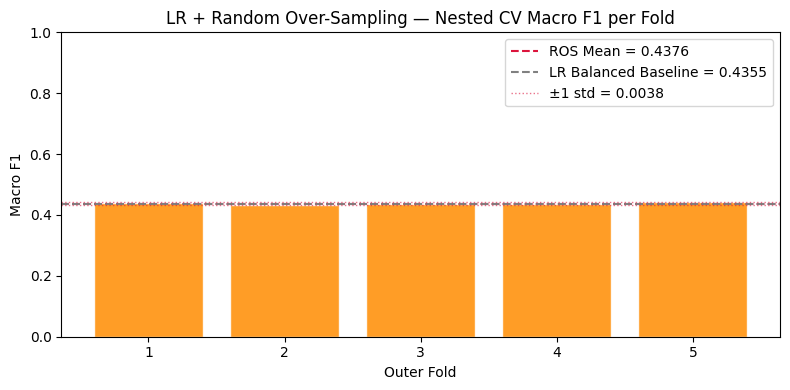

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
folds = list(range(1, 6))
ax.bar(folds, outer_scores, color='darkorange', edgecolor='white', alpha=0.85)
ax.axhline(np.mean(outer_scores), color='crimson', linestyle='--', linewidth=1.5,
           label=f'ROS Mean = {np.mean(outer_scores):.4f}')
ax.axhline(BASELINE_F1, color='grey', linestyle='--', linewidth=1.5,
           label=f'LR Balanced Baseline = {BASELINE_F1:.4f}')
ax.axhline(np.mean(outer_scores) + np.std(outer_scores), color='crimson',
           linestyle=':', linewidth=1, alpha=0.6)
ax.axhline(np.mean(outer_scores) - np.std(outer_scores), color='crimson',
           linestyle=':', linewidth=1, alpha=0.6,
           label=f'±1 std = {np.std(outer_scores):.4f}')
ax.set_xlabel('Outer Fold')
ax.set_ylabel('Macro F1')
ax.set_title('LR + Random Over-Sampling — Nested CV Macro F1 per Fold')
ax.set_xticks(folds)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
print('Best hyperparameters across outer folds:')
param_counts = Counter([str(p) for p in best_params_log])
for params, count in param_counts.most_common():
    print(f'  {count:2d} fold(s): {params}')

Best hyperparameters across outer folds:
   2 fold(s): {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
   2 fold(s): {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
   1 fold(s): {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


## Final Model

Re-run `GridSearchCV` on the **full training set** to select the best `C`, then evaluate on the held-out test set **once**.

In [8]:
print('Fitting final model on full training set...\n')

final_pipeline = ImbPipeline([
    ('ros', RandomOverSampler(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=2000))
])
final_gs = GridSearchCV(
    final_pipeline, param_grid,
    cv=inner_cv, scoring='f1_macro',
    n_jobs=-1, refit=True
)
final_gs.fit(X_train, y_train)

print(f'Best params      : {final_gs.best_params_}')
print(f'Best inner CV F1 : {final_gs.best_score_:.4f}')

Fitting final model on full training set...

Best params      : {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best inner CV F1 : 0.4375


## Test Set Evaluation

> Evaluate on `test_multiclass.csv` **once only** — this is the final performance number.

In [9]:
final_model = final_gs.best_estimator_
y_pred_test = final_model.predict(X_test)

test_macro_f1 = f1_score(y_test, y_pred_test, average='macro')
print(f'Test set Macro F1 : {test_macro_f1:.4f}')
print(f'LR Balanced       : {BASELINE_F1:.4f}')
print(f'Improvement       : {test_macro_f1 - BASELINE_F1:+.4f}\n')
print('Classification Report (Test Set):')
print(classification_report(y_test, y_pred_test, labels=CLASS_ORDER, target_names=CLASS_ORDER))

Test set Macro F1 : 0.4352
LR Balanced       : 0.4355
Improvement       : -0.0003

Classification Report (Test Set):
              precision    recall  f1-score   support

        Good       0.80      0.63      0.70      7168
       Mixed       0.38      0.29      0.33      3208
         Bad       0.18      0.61      0.28       955

    accuracy                           0.53     11331
   macro avg       0.45      0.51      0.44     11331
weighted avg       0.63      0.53      0.56     11331



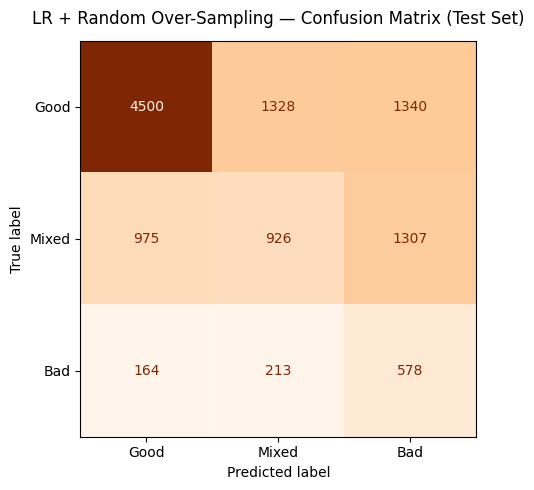

In [10]:
cm = confusion_matrix(y_test, y_pred_test, labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
disp.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('LR + Random Over-Sampling — Confusion Matrix (Test Set)', pad=12)
plt.tight_layout()
plt.show()

## Feature Importance

`final_model` is an `ImbPipeline` — access the classifier step via `.named_steps['clf']`.  
Interpretation is identical to plain Logistic Regression: larger absolute coefficient = stronger feature for that class.

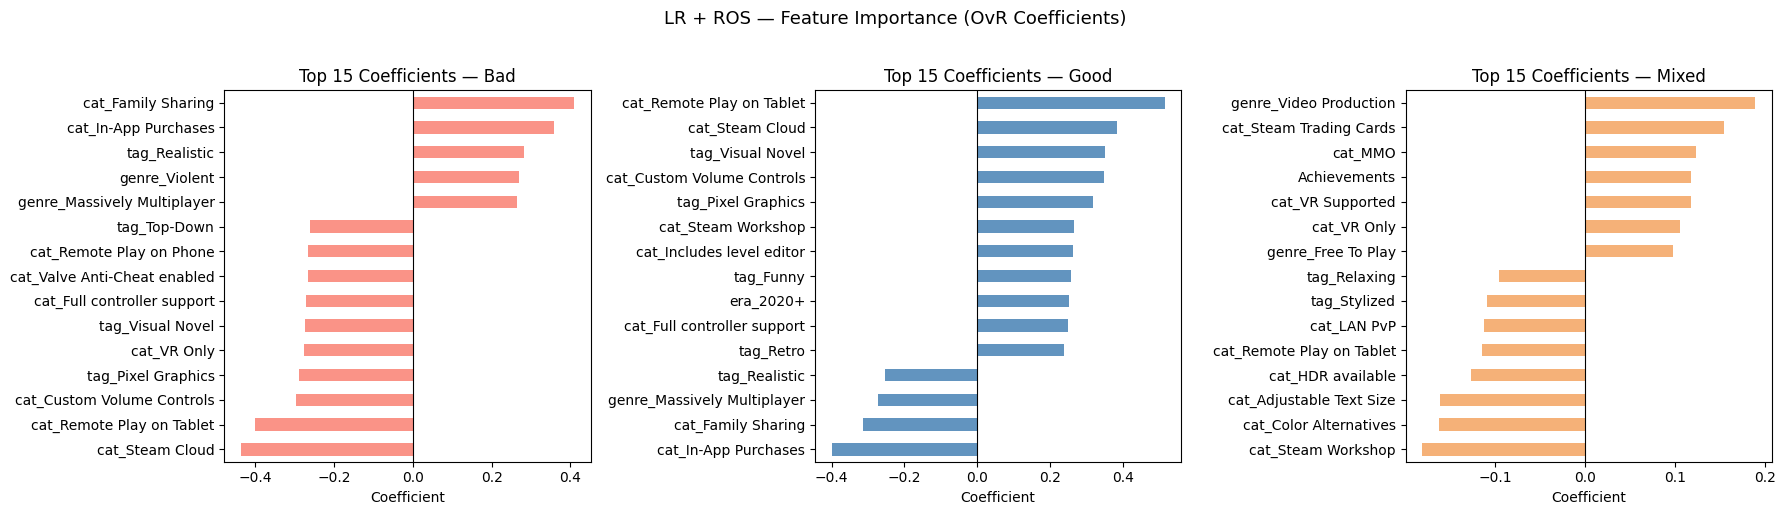

In [11]:
clf_step = final_model.named_steps['clf']
feature_names = X_train.columns.tolist()
coef = clf_step.coef_   # shape: (n_classes, n_features)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, cls in enumerate(clf_step.classes_):
    color = CLASS_COLORS[cls]
    coef_series = pd.Series(coef[i], index=feature_names)
    top_idx = coef_series.abs().nlargest(15).index
    coef_series[top_idx].sort_values().plot(
        kind='barh', ax=axes[i], color=color, alpha=0.85
    )
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'Top 15 Coefficients — {cls}')
    axes[i].set_xlabel('Coefficient')

plt.suptitle('LR + ROS — Feature Importance (OvR Coefficients)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Results Summary

| Metric | Value |
|--------|-------|
| Nested CV Macro F1 (mean ± std) | — |
| Test set Macro F1 | — |
| Best params (final model) | — |
| vs LR Balanced baseline (0.4355) | — |

**Per-class F1 (test set):**

| Class | Precision | Recall | F1 |
|-------|-----------|--------|----|
| Good  | — | — | — |
| Mixed | — | — | — |
| Bad   | — | — | — |

**Interpretation:**

> Fill in after running. Key question: does ROS improve Macro F1 over `class_weight='balanced'`?  
> If not (or only marginally), this confirms `class_weight='balanced'` is the right choice —  
> simpler, no data inflation, no leakage risk, and equivalent performance.